In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
## Output folder for figures
out_dir = Path("output")
out_dir.mkdir(exist_ok=True)

In [3]:
## Load PCF curves and peak table
pcf_all = pd.read_csv('processed_data/pcf_curve_ALL.csv')
peaks = pd.read_csv('processed_data/pcf_peak_table_ALL.csv')

## Factor ordering + labels
lek_order = ['TalChhapar_TC', 'Velavadar_LEK1', 'Velavadar_LEK2']
lek_labels = {'TalChhapar_TC': 'Tal Chhapar', 'Velavadar_LEK1': 'Velavadar Lek 1','Velavadar_LEK2': 'Velavadar Lek 2'}

pcf_all['lek_id'] = (pd.Categorical(pcf_all['lek_id'],categories=lek_order,ordered=True).rename_categories(lek_labels))
peaks['lek_id'] = (pd.Categorical(peaks['lek_id'],categories=lek_order,ordered=True).rename_categories(lek_labels))

In [4]:
## Colour palettes
fill_cols = {'Tal Chhapar': '#B5542D', 'Velavadar Lek 1': '#1F6F8B', 'Velavadar Lek 2': '#3FA7A3'}
point_cols = {'Tal Chhapar': '#D97A52', 'Velavadar Lek 1': '#15556B', 'Velavadar Lek 2': '#2B7E7B'}

lek_labels_ordered = pcf_all['lek_id'].cat.categories.tolist()

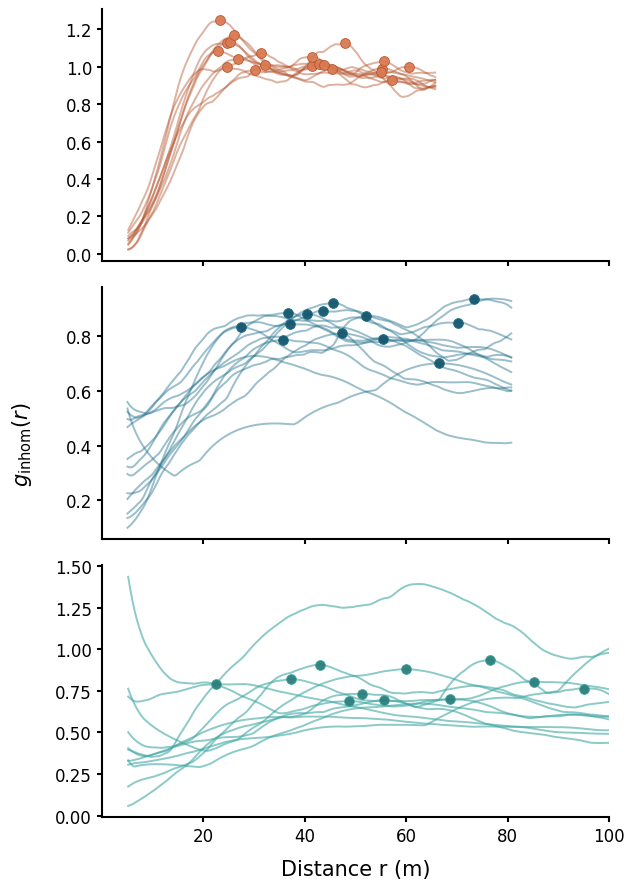

In [5]:
## PCF curves with detected peaks on metric scale
fig, axes = plt.subplots(len(lek_labels), 1, figsize=(6, 9), sharex=True)

for ax, lek in zip(axes, lek_labels_ordered):
    sub_all = pcf_all.loc[(pcf_all['lek_id'] == lek)]
    sub_peaks = peaks.loc[(peaks['lek_id'] == lek)]
    
    for _, gdat in sub_all.groupby('date'):
        ax.plot(gdat['r'], gdat['g'], linewidth=1.4, 
                alpha=0.45 if lek != 'Velavadar Lek 2' else 0.6, color=fill_cols[lek])
    
    scaling_factor = np.unique(sub_all.loc[sub_all['lek_id'] == np.unique(sub_peaks['lek_id'])[0], 'ref_median_nn'])[0]
    ax.scatter(sub_peaks['r_peak'], sub_peaks['g_peak'], s=50, color=point_cols[lek], 
               edgecolor=fill_cols[lek], linewidth=0.6, alpha=0.95, zorder=3)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

for ax in axes:
    ax.set_xticks([20, 40, 60, 80, 100])
    ax.set_xlim(0, 100)
    
axes[-1].set_xlabel('Distance r (m)', fontsize=15, labelpad=10)
fig.text(-0.05, 0.5, r'$g_{\mathrm{inhom}}(r)$',fontsize=15, va='center', rotation='vertical')

plt.tight_layout()

plt.savefig(out_dir/'plot_pcf_curves.png', dpi=300, bbox_inches='tight')

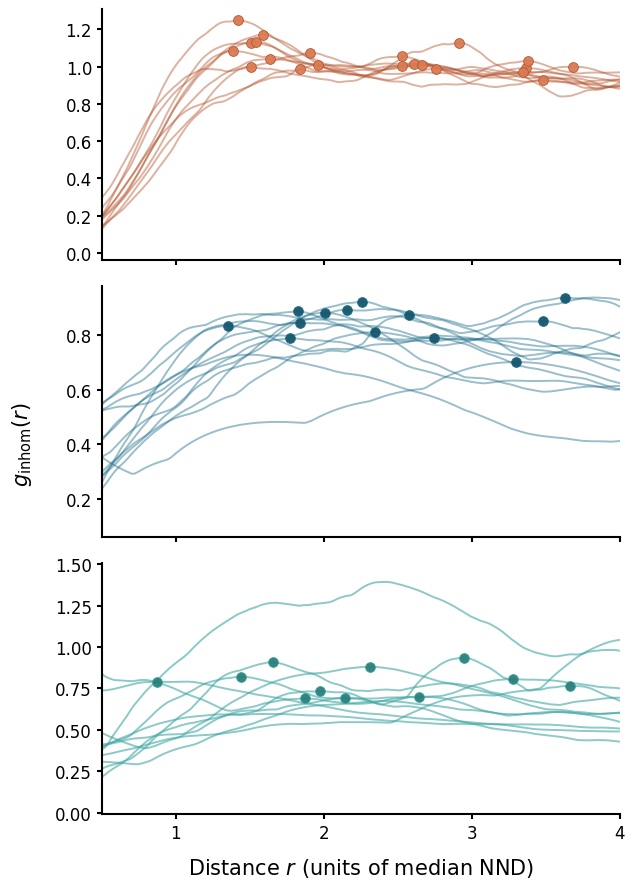

In [6]:
## PCF curves with detected peaks on NND scale
fig, axes = plt.subplots(len(lek_labels), 1, figsize=(6, 9), sharex=True)

for ax, lek in zip(axes, lek_labels_ordered):
    sub_all = pcf_all.loc[(pcf_all['lek_id'] == lek)]
    sub_peaks = peaks.loc[(peaks['lek_id'] == lek)]
    
    for _, gdat in sub_all.groupby('date'):
        ax.plot(gdat['r'] / gdat['ref_median_nn'], gdat['g'], linewidth=1.4, 
                alpha=0.45 if lek != 'Velavadar Lek 2' else 0.6, color=fill_cols[lek])
    
    scaling_factor = np.unique(sub_all.loc[sub_all['lek_id'] == np.unique(sub_peaks['lek_id'])[0], 'ref_median_nn'])[0]
    ax.scatter(sub_peaks['r_peak'] / scaling_factor, sub_peaks['g_peak'], s=50, color=point_cols[lek], 
               edgecolor=fill_cols[lek], linewidth=0.6, alpha=0.95, zorder=3)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

for ax in axes:
    ax.set_xticks([1, 2, 3, 4])
    ax.set_xlim(0.5, 4)
    
axes[-1].set_xlabel(r'Distance $r$ (units of median NND)', fontsize=15, labelpad=10)
fig.text(-0.05, 0.5, r'$g_{\mathrm{inhom}}(r)$',fontsize=15, va='center', rotation='vertical')

plt.tight_layout()

plt.savefig(out_dir/'plot_pcf_curves_rescaled.png', dpi=300, bbox_inches='tight')

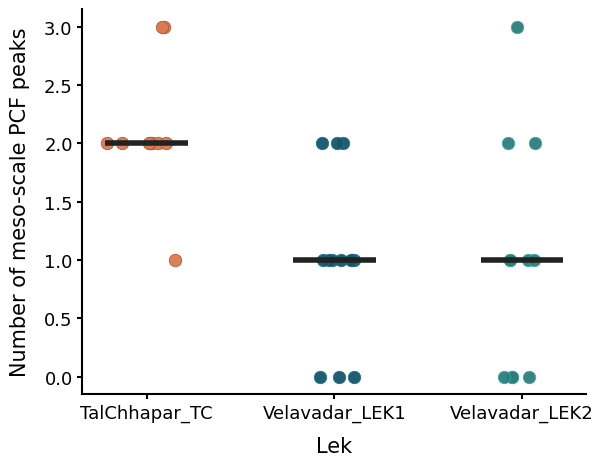

In [7]:
# One row per lek × date
peaks_npeaks = (peaks[['lek_id', 'date', 'n_peaks']].drop_duplicates())

## Number of peaks per date
fig, ax = plt.subplots(figsize=(6.5, 5))

for i, lek in enumerate(lek_labels_ordered):
    
    y = peaks_npeaks.loc[peaks_npeaks['lek_id'] == lek, 'n_peaks'].values
    x = np.random.normal(i + 1, 0.08, size=len(y))
    
    # Jittered points
    ax.scatter(x, y, s=80, color=point_cols[lek], edgecolor=fill_cols[lek], linewidth=0.6, alpha=0.95, zorder=3)
    
    # Median bar
    med = np.median(y)
    ax.hlines(med, i + 1 - 0.22, i + 1 + 0.22, linewidth=4, color='#222222', zorder=4)

# Axis styling
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', labelsize=13, width=1.5)
ax.set_xticks(range(1, len(lek_labels) + 1))
ax.set_xticklabels(lek_labels)

ax.set_xlabel('Lek', fontsize=15, labelpad=10)
ax.set_ylabel('Number of meso-scale PCF peaks', fontsize=15, labelpad=10)

plt.savefig(out_dir / 'summary_pcf_npeaks.png', dpi=300, bbox_inches='tight')

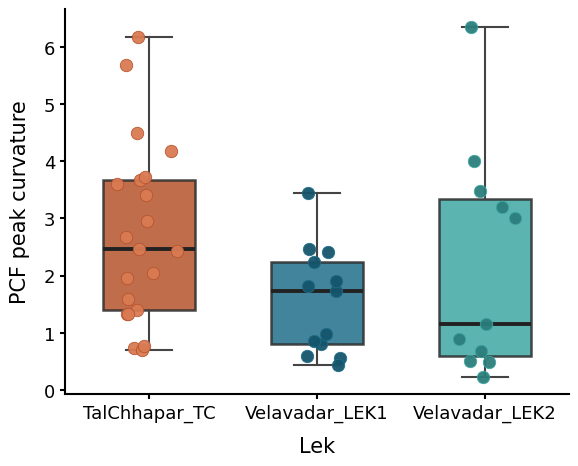

In [8]:
## PCF peak curvature

fig, ax = plt.subplots(figsize=(6.5, 5))

data_by_lek = [peaks.loc[peaks['lek_id'] == lek, 'peak_curvature'].dropna().values for lek in lek_labels_ordered]

bp = ax.boxplot(data_by_lek, widths=0.55, patch_artist=True, showfliers=False,
                boxprops=dict(color='#2B2B2B', linewidth=1.8),
                medianprops=dict(color='#222222', linewidth=2.8), whiskerprops=dict(linewidth=1.5, color='#444444'),
                capprops=dict(linewidth=1.5, color='#444444'))

for patch, lek in zip(bp['boxes'], lek_labels_ordered):
    patch.set_facecolor(fill_cols[lek])
    patch.set_alpha(0.85)

for i, lek in enumerate(lek_labels_ordered):
    y = peaks.loc[peaks['lek_id'] == lek, 'peak_curvature'].values
    x = np.random.normal(i + 1, 0.08, size=len(y))
    ax.scatter(x, y, s=80, color=point_cols[lek], edgecolor=fill_cols[lek], linewidth=0.6, alpha=0.95, zorder=3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', labelsize=13, width=1.5)
ax.set_xticklabels(lek_labels)
ax.set_xlabel('Lek', fontsize=15, labelpad=10)
ax.set_ylabel('PCF peak curvature', fontsize=15, labelpad=10)

plt.savefig(out_dir/'summary_pcf_curvature.png', dpi=300, bbox_inches='tight')